# 2 Modelo ARIMA: 

ARIMA es uno de los enfoques más utilizados para la previsión de series temporales y se puede utilizar de dos maneras diferentes en función del tipo de datos de series temporales con los que se trabaje. En el primer caso, un modelo ARIMA no estacional que no requiere tener en cuenta la estacionalidad en sus datos de series temporales. Predecimos el futuro simplemente basándonos en patrones en los datos pasados. En el segundo caso, tenemos en cuenta la estacionalidad, que son los ciclos regulares que afectan a la serie temporal. Estos ciclos pueden ser diarios, semanales, mensuales, etc... y ayudan a definir patrones en los datos pasados de la serie temporal que se pueden utilizar para pronosticar valores futuros.

## 2.1 Significado de ARIMA(p, d, q)

ARIMA es un acrónimo de:

AR (p) = AutoRegresivo, es decir el presente depende de valores pasados
I(d) = Integral, quitamos tendencia (hacemos la serie estable)
MA (q) = Media Movil, el presente depende de errores pasados

## 2.2 Autoregresivo

En un modelo de autorregresión, pronosticamos la variable de interés utilizando una combinación lineal de valores pasados de la variable. El término autorregresión indica que se trata de una regresión de la variable contra sí misma. Esta técnica es similar a un modelo de regresión lineal en cuanto a que utiliza los valores del pasado como entradas para la regresión. La autorregresión se define como:

## 2.3 Media Movil

## 2.4 Integral

## 2.5 Autocorrelación




### Ejemplo código python:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


# ------------------------------
# 1. Cargar los datos
# ------------------------------
df = pd.read_csv('LimpiezaOmiePrecio2020_2024.csv', sep=";")


# ------------------------------
# 2. Convertir la columna de datetime a tipo datetime y ponerla como indice
# ------------------------------
# Convertir la columna de datetime a tipo datetime y ponerla como indice
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)

Tamaño entrenamiento: 35064 horas (1461 días)
Tamaño prueba:        8784 horas  (366 días)
Porcentaje test:      20.0%


c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                35064
Model:                 ARIMA(2, 1, 1)   Log Likelihood             -131787.416
Date:                Tue, 01 Sep 2026   AIC                         263582.832
Time:                        09:56:25   BIC                         263616.691
Sample:                    01-01-2020   HQIC                        263593.616
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3163      0.003    508.629      0.000       1.311       1.321
ar.L2         -0.4985      0.002   -216.397      0.000      -0.503      -0.494
ma.L1         -0.9360      0.002   -596.145      0.0

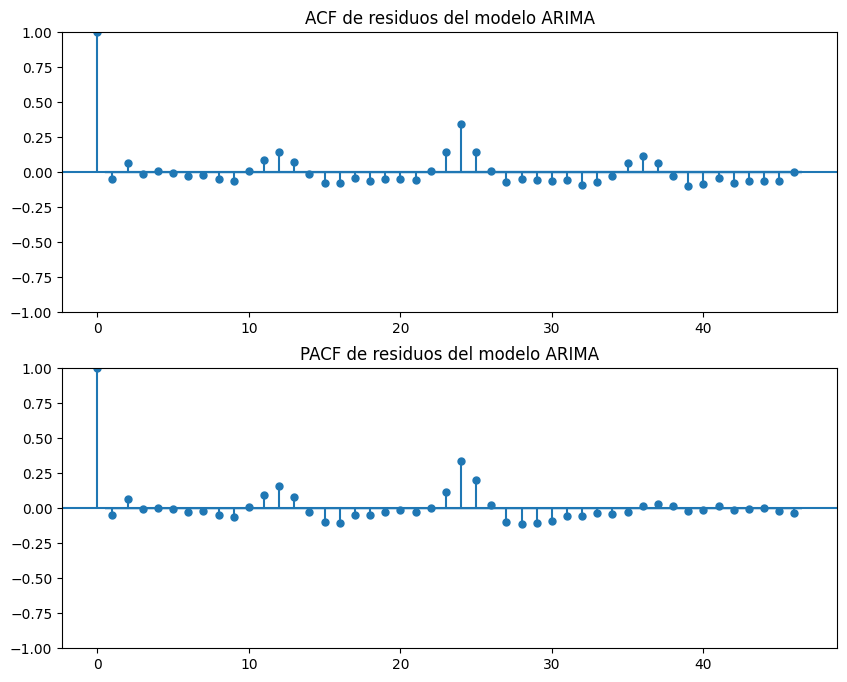


TEST LJUNG-BOX
       lb_stat     lb_pvalue
10  486.712125  3.046000e-98
los residuos NO son ruido blanco (tienen estructura/autocorrelacion)

========== MÉTRICAS DE PRECISIÓN ==========
  MAE   (Error Absoluto Medio):        40.6805 €/MWh
  RMSE  (Raíz Error Cuadrático Medio): 47.3138 €/MWh
  MAPE  (Error Porcentual Medio):       1422532604648371456.00%
  R²    (Coeficiente determinación):    -0.0612
  RMSE modelo naive (benchmark):        12.8171 €/MWh
  El modelo es PEOR que el naive



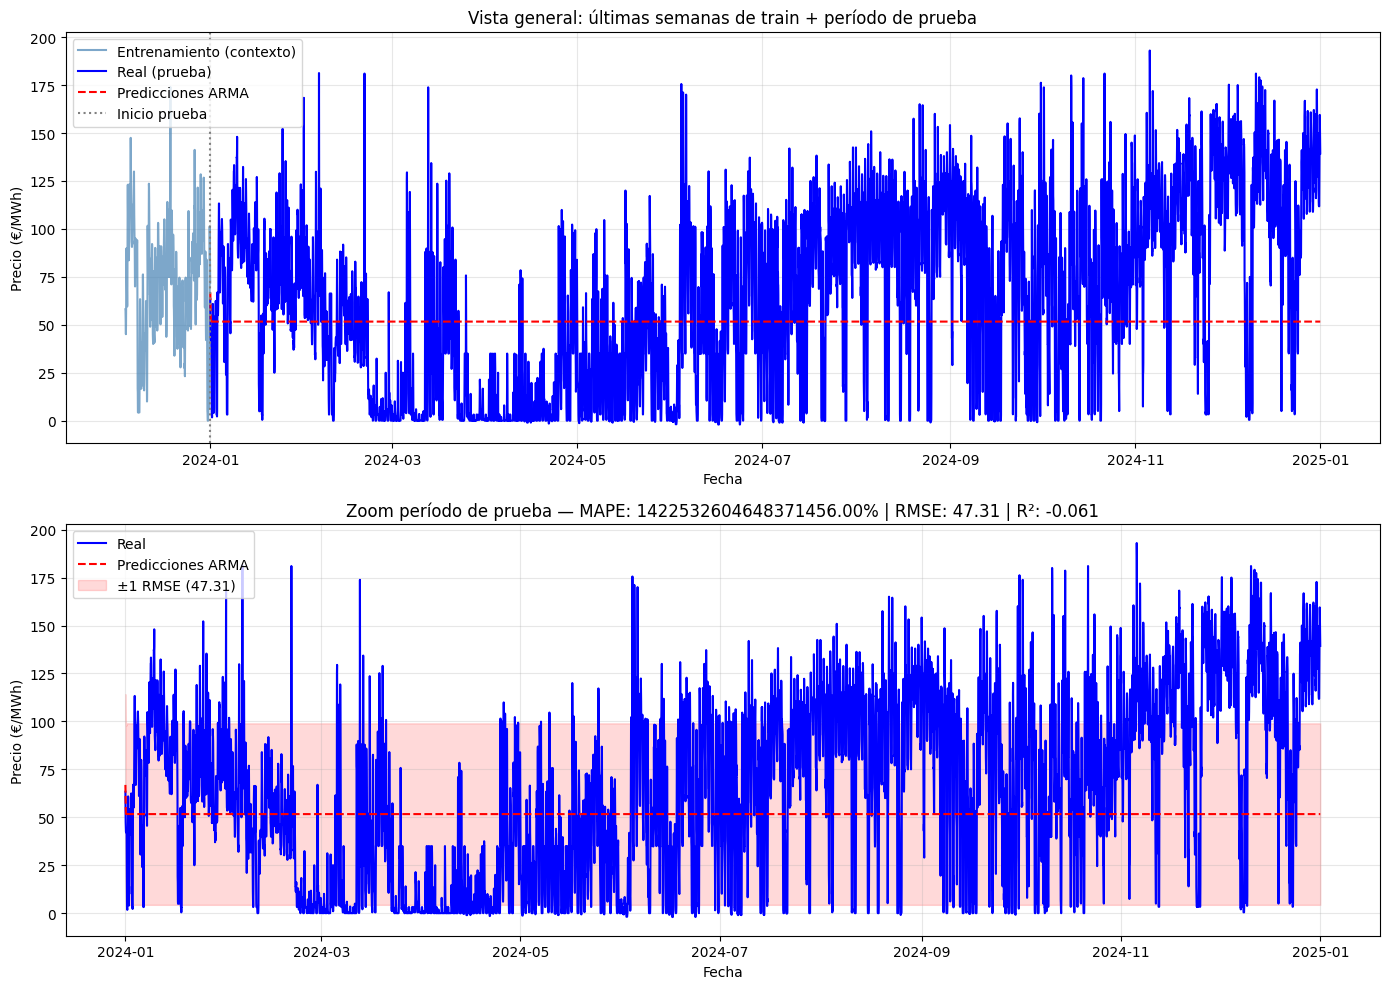


¡Archivo 'predicciones_arima_2024.csv' generado con éxito!


In [3]:
# ==============================
# 3. División en entrenamiento y prueba
# ==============================
# 

train = df[df.index.year < 2024]
test  = df[df.index.year == 2024]

# Seleccionamos la columna de precio (la que queremos predecir)
serie_train = train['price'] 
serie_test = test['price']

# Asigna frecuencia, para nosostros h para una frecuencia en horas
train = serie_train.asfreq('h')   # o 'd' para dias
test = serie_test.asfreq('h')   

print(f"Tamaño entrenamiento: {len(train)} horas ({len(train)/24:.0f} días)")
print(f"Tamaño prueba:        {len(test)} horas  ({len(test)/24:.0f} días)")
print(f"Porcentaje test:      {100*len(test)/(len(serie_train)+len(serie_test)):.1f}%")

# ==============================
# 5. Elegir los órdenes p y q del modelo ARIMA
# ==============================
# En Box-Jenkins a partir de los gráficos de ACF y PACF, elegimos p y q
# En nuestro caso fueron p=2 y q=1
# El valor d e sel numero de diferenciaciones para hacer la serie estacionaria,
#  pero como la serie ya es estacionaria, no es necesario diferenciar (d=0)
#  aunque se puede poner d=1 sin que cambie el resultado matemático porque
#  ARIMA con d=1 en una serie ya estacionaria es equivalente a ARMA con d=0
p = 2
d = 1
q = 1
# En ARIMA, el orden es (p, d, q).
modelo = ARIMA(train, order=(p, d, q))

# Ajustar el modelo
modelo_ajustado = modelo.fit()

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())


# ==============================
# 5.2. Verificar residuos (validación)
# ==============================

# Verificar residuos (validación)
residuos = modelo_ajustado.resid

# Gráfico ACF de residuos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(residuos, ax=axes[0])
axes[0].set_title('ACF de residuos del modelo ARIMA')

plot_pacf(residuos, ax=axes[1])
axes[1].set_title('PACF de residuos del modelo ARIMA')
plt.show()

# Prueba de Ljung-Box (si p-value > 0.05 los residuos son ruido blanco)
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(f"\nTEST LJUNG-BOX")
print(lb_test.to_string())
if (lb_test['lb_pvalue'] > 0.05).all():
    print("los residuos son ruido blanco")
else:
    print("los residuos NO son ruido blanco (tienen estructura/autocorrelacion)")

# ==============================
# 6. Predecir los valores del conjunto de prueba
# ==============================
# forecast recibe el número de pasos a predecir
predicciones = modelo_ajustado.forecast(steps=len(test))
predicciones.index = test.index   # para que luego se pueda gaficar bien

# ==============================
# 7. AMPLIADA - Métricas de precisión
# ==============================
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae  = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = mean_absolute_percentage_error(test, predicciones) * 100

# Métrica adicional: R² (qué % de varianza explica el modelo)
ss_res = np.sum((test - predicciones) ** 2)
ss_tot = np.sum((test - test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Naive benchmark: predecir siempre el valor anterior (lag-1)
naive_pred = test.shift(1).dropna()
rmse_naive = np.sqrt(mean_squared_error(test[1:], naive_pred))

print("\n========== MÉTRICAS DE PRECISIÓN ==========")
print(f"  MAE   (Error Absoluto Medio):        {mae:.4f} €/MWh")
print(f"  RMSE  (Raíz Error Cuadrático Medio): {rmse:.4f} €/MWh")
print(f"  MAPE  (Error Porcentual Medio):       {mape:.2f}%")
print(f"  R²    (Coeficiente determinación):    {r2:.4f}")
print(f"  RMSE modelo naive (benchmark):        {rmse_naive:.4f} €/MWh")
print(f"  El modelo es {'MEJOR' if rmse < rmse_naive else 'PEOR'} que el naive")
print("============================================\n")

# ==============================
# 8. CORREGIDA - Gráficas con zoom y separadas
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfica 1: visión global (últimas 4 semanas de train + todo el test) ---
CONTEXTO = 672  # horas de entrenamiento que se muestran como contexto

ax1 = axes[0]
ax1.plot(train[-CONTEXTO:].index, train[-CONTEXTO:],
         label='Entrenamiento (contexto)', color='steelblue', alpha=0.7)
ax1.plot(test.index, test,
         label='Real (prueba)', color='blue', linewidth=1.5)
ax1.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax1.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.5,
            label='Inicio prueba')
ax1.set_title('Vista general: últimas semanas de train + período de prueba')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (€/MWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: zoom solo en el período de prueba ---
ax2 = axes[1]
ax2.plot(test.index, test,
         label='Real', color='blue', linewidth=1.5)
ax2.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax2.fill_between(test.index,
                 predicciones - rmse,
                 predicciones + rmse,
                 alpha=0.15, color='red', label=f'±1 RMSE ({rmse:.2f})')
ax2.set_title(f'Zoom período de prueba — MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | R²: {r2:.3f}')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Precio (€/MWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arima_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()

# =======================================================================================
# 9. EXPORTAR Y GUARDAR RESULTADOS (MODELO ARIMA)
# =======================================================================================
# Creamos un nuevo dataframe para comparar la realidad vs la predicción de ARIMA
df_resultados_arima = pd.DataFrame({
    'Precio_Real': serie_test,
    'Prediccion_ARIMA': predicciones,
    'Diferencia_ARIMA': serie_test - predicciones
}, index=serie_test.index)

# Añadimos variables temporales al dataframe de resultados para agrupar
df_resultados_arima['hour'] = df_resultados_arima.index.hour
df_resultados_arima['month'] = df_resultados_arima.index.month


# Guardamos los resultados en un archivo CSV específico para ARIMA
df_resultados_arima.to_csv('predicciones_arima_2024.csv')
print("\n¡Archivo 'predicciones_arima_2024.csv' generado con éxito!")

Resultado:

Aunque la serie es estacionaria según el test ADF, los modelos ARMA/ARIMA no capturan adecuadamente la estructura de dependencia temporal debido a la presencia de estacionalidad, lo que se traduce en un bajo rendimiento predictivo.

El problema no es la no estacionariedad, es:

Estacionalidad NO modelada. La serie puede ser estacionaria en media pero tener patrones periódicos (diarios, semanales...). ARMA no captura eso bien, por eso:

ACF tiene picos en lags tipo 24, 48, etc.
Y el modelo falla en la predicción


Esto justifica el uso de modelos SARIMA, que incorporan componentes estacionales explícitos.

### Visualización de las prediciones en una ventana de tiempo

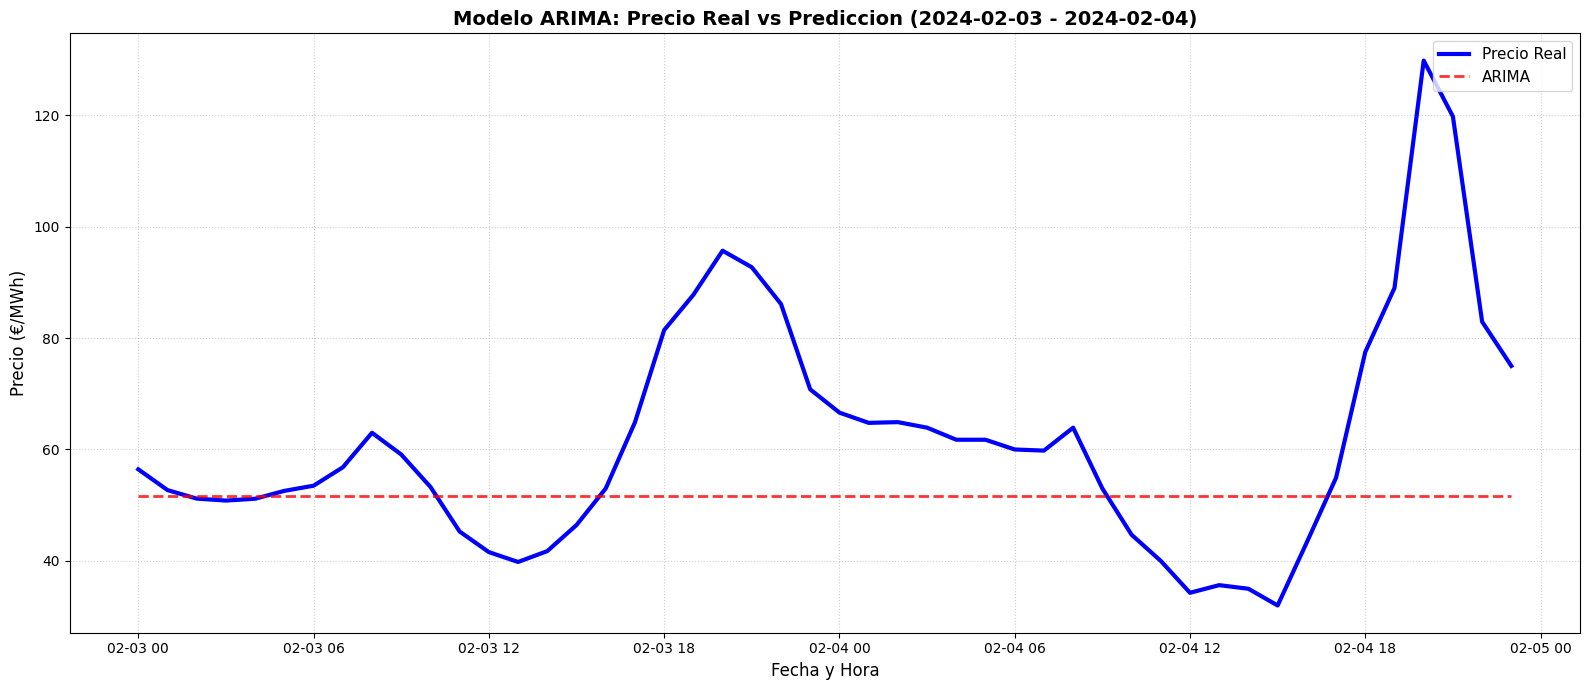

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 7. VISUALIZACION DE RESULTADOS (MODELO ARIMA)
# =======================================================================================
# Cargamos el archivo de predicciones ARIMA
df_resultados_csv = pd.read_csv('predicciones_arima_2024.csv', index_col=0, parse_dates=True)

# Filtramos un tramo corto (ej. ultima semana de julio 2024)
df_plot = df_resultados_csv.loc['2024-02-03':'2024-02-04']

plt.figure(figsize=(16, 7))

# 1. Linea del Precio Real (Azul, continua y mas gruesa para que destaque)
plt.plot(df_plot.index, df_plot['Precio_Real'], 
         label='Precio Real', color='blue', linewidth=3)

# 2. Linea de Prediccion ARIMA (Rojo, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_ARIMA'], 
         label='ARIMA', color='red', linestyle='--', linewidth=2, alpha=0.8)

# Añadimos titulos y diseño
plt.title('Modelo ARIMA: Precio Real vs Prediccion (' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Precio (€/MWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Guardamos y mostramos
plt.savefig('grafico_arima_(' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')_2024.png', dpi=300)
plt.show()

#### Gráfica del MAE (error medio)

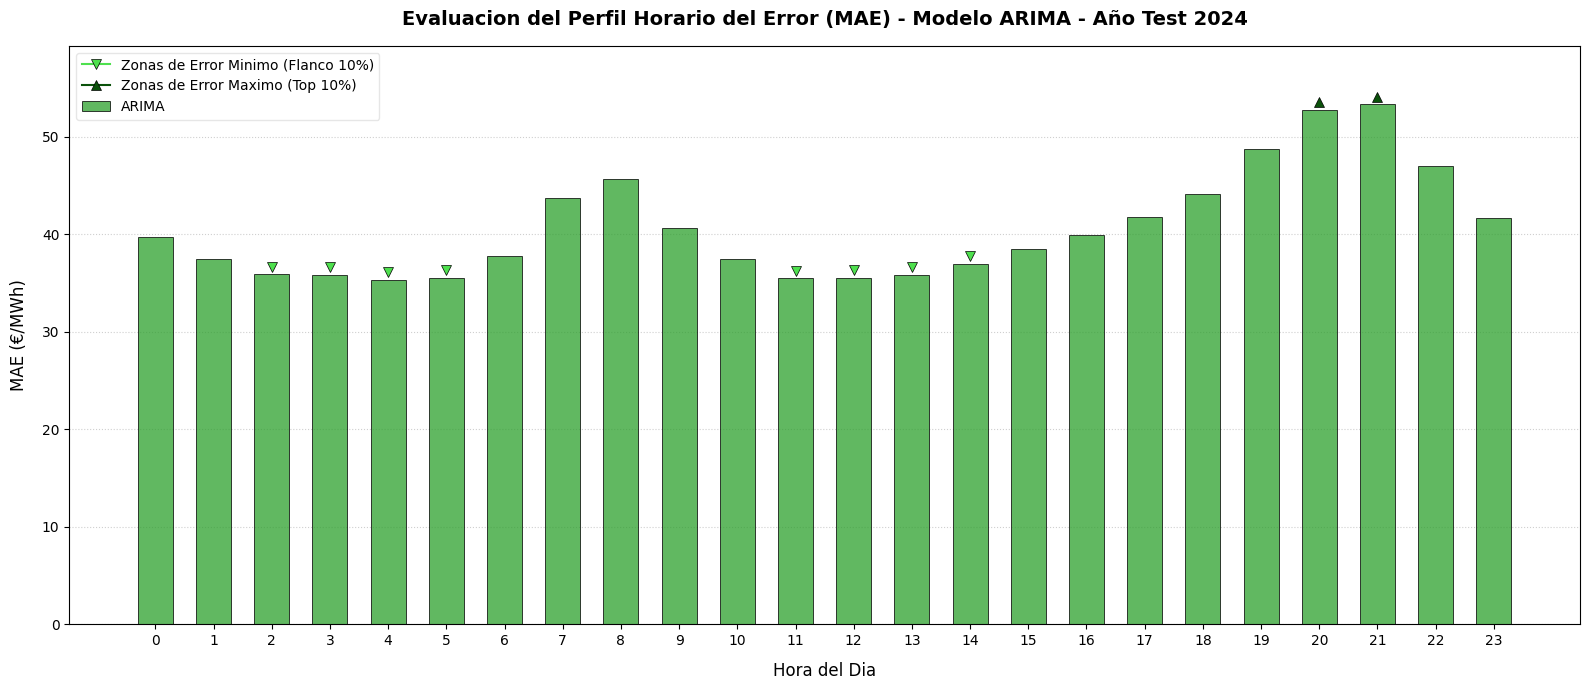

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =======================================================================================
# 8. ANALISIS HORARIO DEL ERROR (MODELO ARIMA - DESDE CSV)
# =======================================================================================

# 1. Carga y calculo dinamico de metricas por hora
df_resultados_csv = pd.read_csv('predicciones_arima_2024.csv', index_col=0, parse_dates=True)
mae_arima = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_ARIMA']))

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.6

# 2. Dibujo de las barras
barras_arima = ax.bar(horas, mae_arima, width=ancho_barra, label='ARIMA', color='#2ca02c', alpha=0.75, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACION Y MARCADO DE ERRORES MAXIMOS Y MINIMOS
# ---------------------------------------------------------------------------------------
max_val = mae_arima.max()
min_val = mae_arima.min()
rango_total = max_val - min_val

limite_alto = max_val - (0.10 * rango_total)
limite_bajo = min_val + (0.10 * rango_total)

legend_max_added = False
legend_min_added = False

for hora in horas:
    valor_mae = mae_arima[hora]
    posicion_x = hora
    
    # Caso A: Errores maximos o en el 10% superior (Flecha hacia arriba '^')
    if valor_mae >= limite_alto:
        label_text = 'Zonas de Error Maximo (Top 10%)' if not legend_max_added else ""
        ax.plot(posicion_x, valor_mae + 0.8, marker='^', color='#0b520b', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_max_added = True
        
    # Caso B: Errores minimos o en el 10% inferior (Flecha hacia abajo 'v')
    elif valor_mae <= limite_bajo:
        label_text = 'Zonas de Error Minimo (Flanco 10%)' if not legend_min_added else ""
        ax.plot(posicion_x, valor_mae + 0.8, marker='v', color='#4ee04e', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluacion del Perfil Horario del Error (MAE) - Modelo ARIMA - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('MAE (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Limites del eje Y holgados para que no se solape con la leyenda
ax.set_ylim(0, mae_arima.max() + 6)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_error_horario_arima_2024.png', dpi=300)
plt.show()

#### Grafica del Error Modal

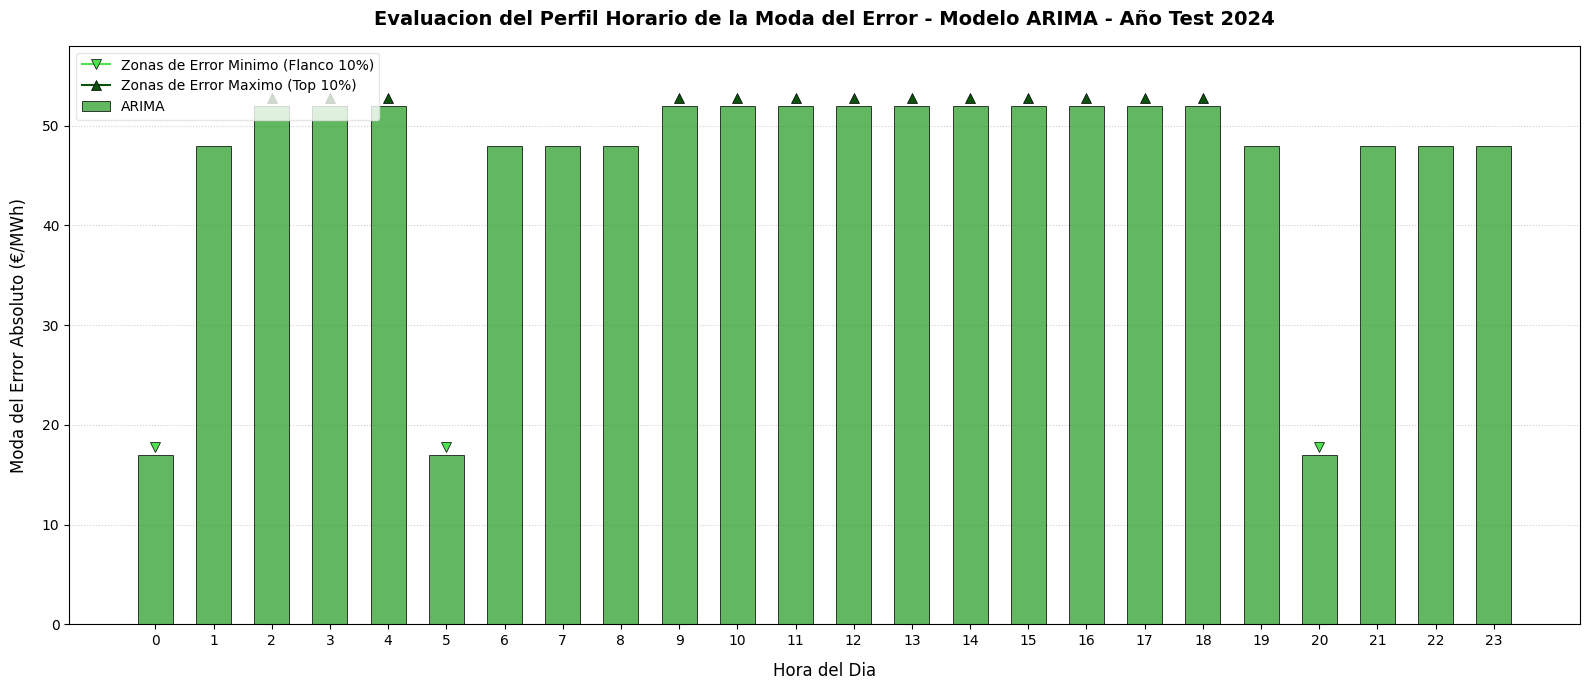

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 8. ANALISIS HORARIO DEL ERROR (MODA DEL ERROR ABSOLUTO - ARIMA)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_arima_2024.csv', index_col=0, parse_dates=True)

# Funcion interna para calcular la moda del error absoluto redondeado a enteros
def calcular_moda_error(df, col_pred):
    # Calculamos el error absoluto por cada fila
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    # Redondeamos a enteros para permitir que existan valores repetidos (Moda)
    error_redondeado = error_absoluto.round(0)
    # Agrupamos por hora y extraemos el valor mas frecuente (la moda)
    return error_redondeado.groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)

# Calculo dinamico de la moda del error por hora para ARIMA
moda_arima = calcular_moda_error(df_resultados_csv, 'Prediccion_ARIMA')

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.6

# 2. Dibujo de las barras base
barras_arima = ax.bar(horas, moda_arima, width=ancho_barra, label='ARIMA', color='#2ca02c', alpha=0.75, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACION Y MARCADO DE ERRORES MAXIMOS Y MINIMOS
# ---------------------------------------------------------------------------------------
max_val = moda_arima.max()
min_val = moda_arima.min()
rango_total = max_val - min_val

limite_alto = max_val - (0.10 * rango_total)
limite_bajo = min_val + (0.10 * rango_total)

legend_max_added = False
legend_min_added = False

for hora in horas:
    valor_actual = moda_arima[hora]
    posicion_x = hora
    
    # Caso A: Valores maximos o en el 10% superior (Flecha hacia arriba '^')
    if valor_actual >= limite_alto:
        label_text = 'Zonas de Error Maximo (Top 10%)' if not legend_max_added else ""
        ax.plot(posicion_x, valor_actual + 0.8, marker='^', color='#0b520b', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_max_added = True
        
    # Caso B: Valores minimos o en el 10% inferior (Flecha hacia abajo 'v')
    elif valor_actual <= limite_bajo:
        label_text = 'Zonas de Error Minimo (Flanco 10%)' if not legend_min_added else ""
        ax.plot(posicion_x, valor_actual + 0.8, marker='v', color='#4ee04e', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluacion del Perfil Horario de la Moda del Error - Modelo ARIMA - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('Moda del Error Absoluto (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Limites del eje Y holgados para que no se solape con la leyenda
ax.set_ylim(0, moda_arima.max() + 6)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_moda_error_horario_arima_2024.png', dpi=300)
plt.show()

#### Gráfica de Errores Extremos

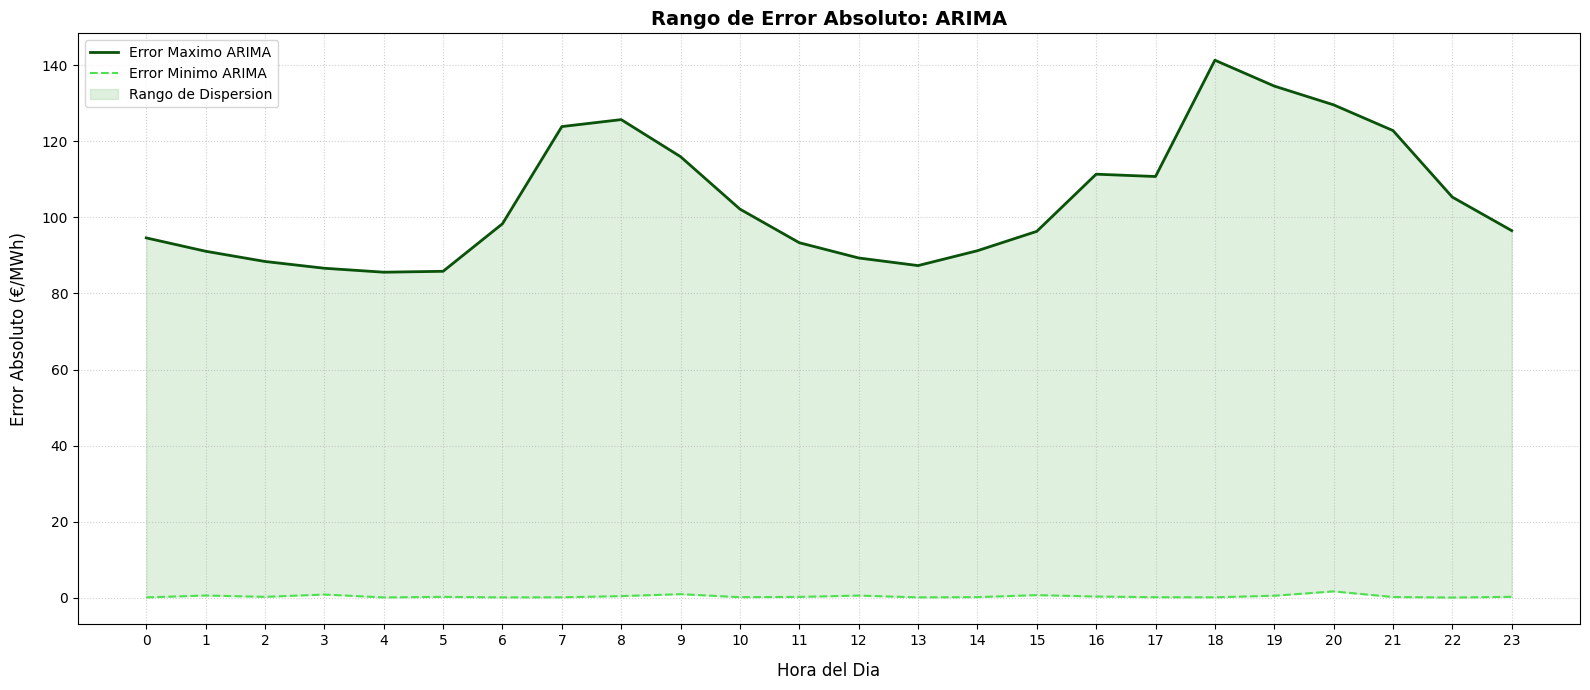

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 9. ANALISIS HORARIO DE ERRORES EXTREMOS (MAXIMOS Y MINIMOS - ARIMA)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_arima_2024.csv', index_col=0, parse_dates=True)

# Funcion para extraer el error absoluto maximo y minimo por hora
def calcular_errores_extremos(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    return err_max, err_min

# Calculo dinamico para ARIMA
max_arima, min_arima = calcular_errores_extremos(df_resultados_csv, 'Prediccion_ARIMA')

horas = np.arange(24)

# Creamos una grafica para ARIMA
fig, ax = plt.subplots(figsize=(16, 7))

# ---------------------------------------------------------------------------------------
# PANEL: ARIMA (Verde)
# ---------------------------------------------------------------------------------------
ax.plot(horas, max_arima, color='#0b520b', linestyle='-', linewidth=2, label='Error Maximo ARIMA')
ax.plot(horas, min_arima, color='#4ee04e', linestyle='--', linewidth=1.5, label='Error Minimo ARIMA')
ax.fill_between(horas, min_arima, max_arima, color='#2ca02c', alpha=0.15, label='Rango de Dispersion')
ax.set_title('Rango de Error Absoluto: ARIMA', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('Error Absoluto (€/MWh)', fontsize=12, labelpad=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=10)

# Configuracion de los ejes
plt.xticks(horas)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_errores_extremos_horarios_arima_2024.png', dpi=300)
plt.show()

#### Comparativa Gráfica de los datos horarios

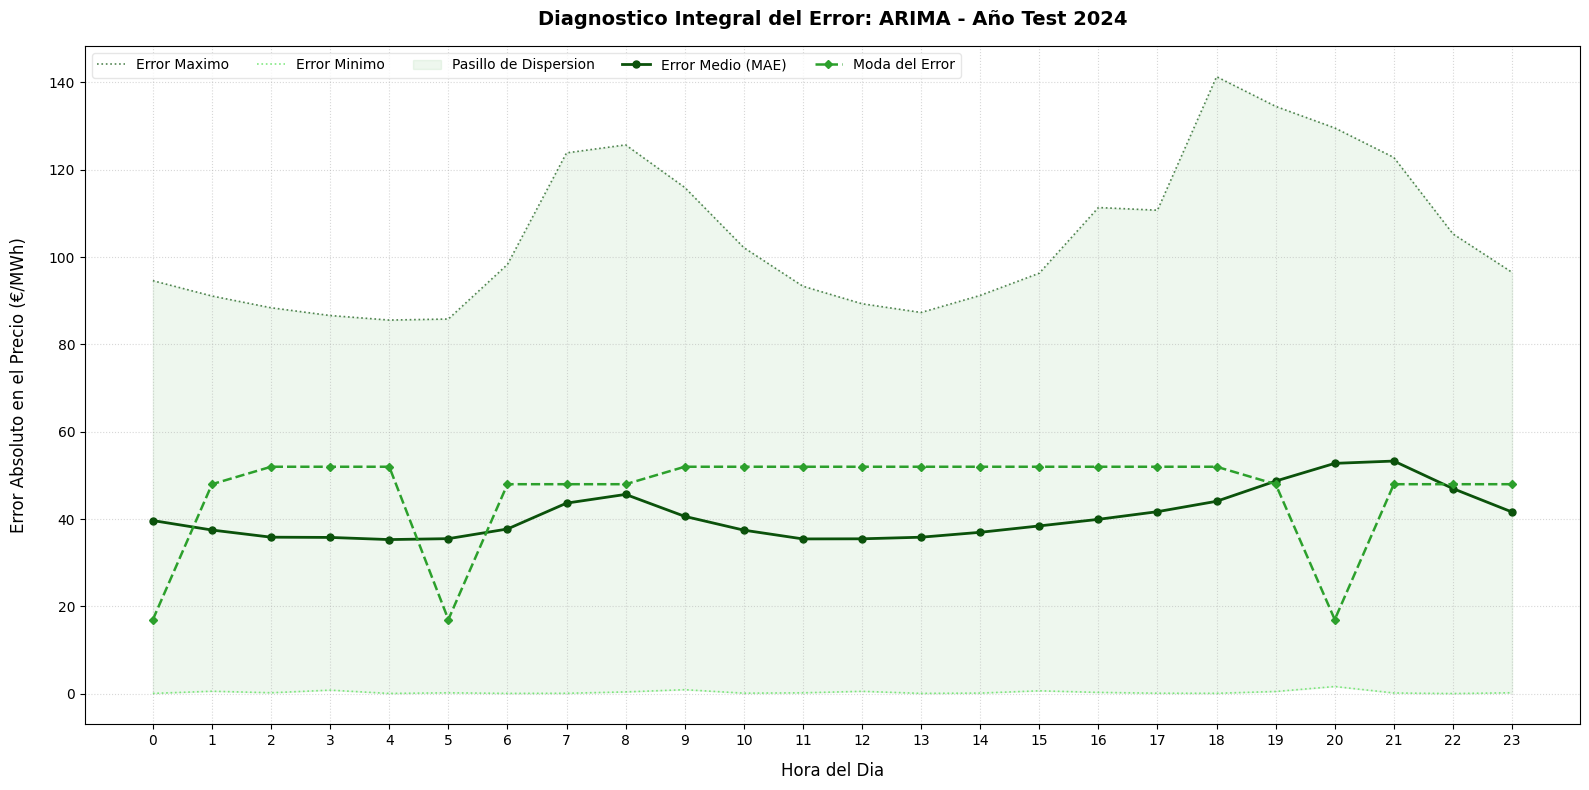

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =======================================================================================
# 10. DIAGNOSTICO INTEGRAL DEL ERROR: MAXIMOS, MINIMOS, MEDIAS Y MODAS (ARIMA)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_arima_2024.csv', index_col=0, parse_dates=True)

# Funcion para calcular todas las metricas horarias de forma limpia
def calcular_metricas_completas(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    err_mean = error_absoluto.groupby(df['hour']).mean()
    err_mode = error_absoluto.round(0).groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)
    
    return err_max, err_min, err_mean, err_mode

# Calculo dinamico para ARIMA
max_arima, min_arima, mean_arima, mode_arima = calcular_metricas_completas(df_resultados_csv, 'Prediccion_ARIMA')

horas = np.arange(24)

# Creamos una grafica para ARIMA
fig, ax = plt.subplots(figsize=(16, 8))

# A. Dibujar el pasillo de dispersion (Maximos y Minimos)
ax.plot(horas, max_arima, color='#0b520b', linestyle=':', linewidth=1.2, alpha=0.7, label='Error Maximo')
ax.plot(horas, min_arima, color='#4ee04e', linestyle=':', linewidth=1.2, alpha=0.7, label='Error Minimo')
ax.fill_between(horas, min_arima, max_arima, color='#2ca02c', alpha=0.08, label='Pasillo de Dispersion')

# B. Dibujar el Comportamiento Central (Media y Moda)
# Media (MAE) con linea discontinua y marcadores redondos
ax.plot(horas, mean_arima, color='#0b520b', linestyle='-', linewidth=2, 
        marker='o', markersize=5, label='Error Medio (MAE)')

# Moda con linea de guiones y marcadores de diamante
ax.plot(horas, mode_arima, color='#2ca02c', linestyle='--', linewidth=1.8, 
        marker='D', markersize=4, label='Moda del Error')

# C. Estetica y formatos
ax.set_title('Diagnostico Integral del Error: ARIMA - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('Error Absoluto en el Precio (€/MWh)', fontsize=12, labelpad=15)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper left', fontsize=10, ncol=5, frameon=True, facecolor='white', edgecolor='#e0e0e0')

plt.xticks(horas)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_diagnostico_integral_errores_arima_2024.png', dpi=300)
plt.show()

### Metricas Accuracy

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error
)

# =======================================================================================
# 11. CALCULO DE METRICAS GLOBALES DE PRECISION Y ROBUSTAS (ARIMA)
# =======================================================================================

# 1. Definicion matematica de funciones porcentuales robustas para el TFG
def calcular_wape(y_true, y_pred):
    """Calcula el Weighted MAPE ponderando por la suma del precio real."""
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def calcular_smape(y_true, y_pred):
    """Calcula el sMAPE acotando el denominador entre el valor real y el predicho."""
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diferencia = np.abs(y_true - y_pred)
    # Manejo de proteccion por si precio real y predicho coinciden en 0.0 €/MWh
    ratio = np.where(denominador == 0, 0.0, diferencia / denominador)
    return np.mean(ratio) * 100


# 2. Cargar el archivo de predicciones guardado
# Asumimos que 'datetime' es la primera columna y sirve como indice temporal
df = pd.read_csv('predicciones_arima_2024.csv', index_col=0, parse_dates=True)

# 3. Definir el modelo ARIMA y su columna de prediccion correspondiente en el CSV
modelos = {
    'ARIMA': 'Prediccion_ARIMA'
}

print("=== METRICAS GLOBALES DE PRECISION (ACCURACY) - AÑO TEST 2024 ===")
resultados = []

# 4. Bucle unificado para calcular TODAS las metricas por cada modelo
for nombre, col_pred in modelos.items():
    # Variables objetivo reales y predichas
    y_true = df['Precio_Real']
    y_pred = df[col_pred]
    
    # Calculo de metricas estandar de Scikit-Learn
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # Formato porcentaje
    medae = median_absolute_error(y_true, y_pred)
    
    # Calculo de metricas porcentuales robustas integradas
    wape_val = calcular_wape(y_true, y_pred)
    smape_val = calcular_smape(y_true, y_pred)
    
    # Calculo del error absoluto y su MODA global (redondeado a 0 decimales)
    error_absoluto = (y_true - y_pred).abs()
    error_redondeado = error_absoluto.round(0)
    # Extrae el primer valor de la moda; si la serie esta vacia asigna 0
    err_mode = error_redondeado.mode().iloc[0] if not error_redondeado.empty else 0.0
    
    # Imprimir por consola de forma limpia y agrupada
    print(f"\n[{nombre}]")
    print(f"  - MAE:       {mae:.3f} €/MWh")
    print(f"  - RMSE:      {rmse:.3f} €/MWh")
    print(f"  - R²:        {r2:.3f}")
    print(f"  - MAPE:      {mape:.2f}%")
    print(f"  - wAPE:      {wape_val:.2f}%")
    print(f"  - sMAPE:     {smape_val:.2f}%")
    print(f"  - MedAE:     {medae:.3f} €/MWh")
    print(f"  - Moda Error:{err_mode:.0f} €/MWh (Redondeado)")
    
    # Guardar todas las metricas redondeadas para el DataFrame final
    resultados.append({
        'Modelo': nombre,
        'MAE (€/MWh)': round(mae, 3),
        'RMSE (€/MWh)': round(rmse, 3),
        'R²': round(r2, 3),
        'MAPE (%)': round(mape, 2),
        'wAPE (%)': round(wape_val, 2),
        'sMAPE (%)': round(smape_val, 2),
        'MedAE (€/MWh)': round(medae, 3),
        'Moda Error (€/MWh)': int(err_mode)
    })

# 5. Guardar una unica tabla resumen limpia para adjuntar a la memoria del TFG
df_resumen = pd.DataFrame(resultados)
df_resumen.to_csv('resumen_metricas_globales_arima_2024.csv', index=False)
print("\nArchivo 'resumen_metricas_globales_arima_2024.csv' generado con exito")

=== METRICAS GLOBALES DE PRECISION (ACCURACY) - AÑO TEST 2024 ===

[ARIMA]
  - MAE:       40.681 €/MWh
  - RMSE:      47.314 €/MWh
  - R²:        -0.061
  - MAPE:      1422532604648371456.00%
  - wAPE:      64.52%
  - sMAPE:     83.03%
  - MedAE:     43.762 €/MWh
  - Moda Error:52 €/MWh (Redondeado)

Archivo 'resumen_metricas_globales_arima_2024.csv' generado con exito


### Representacion del resto de variables de Accurancy

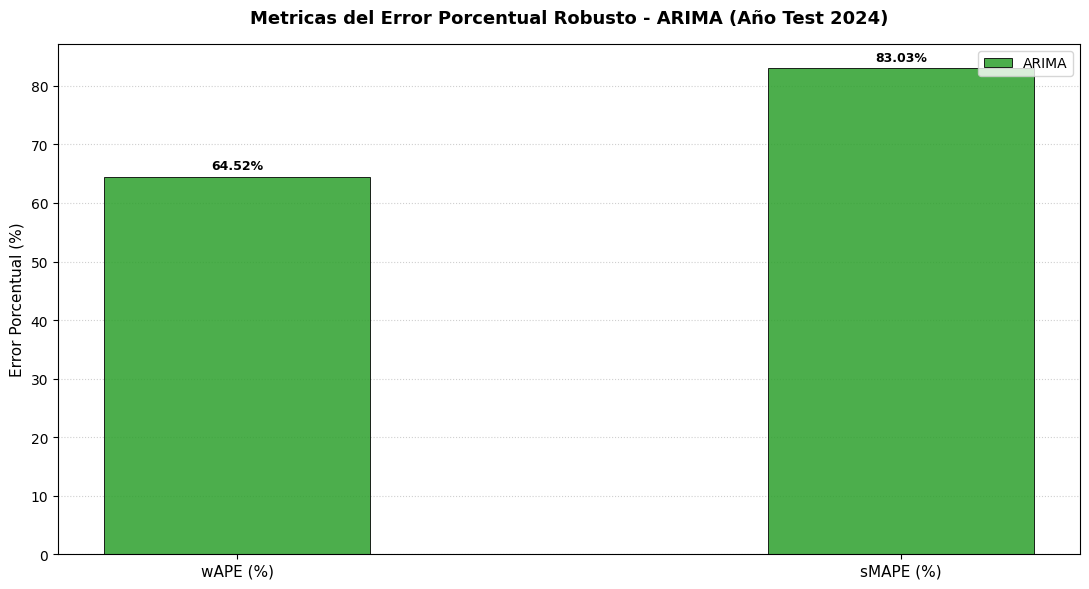

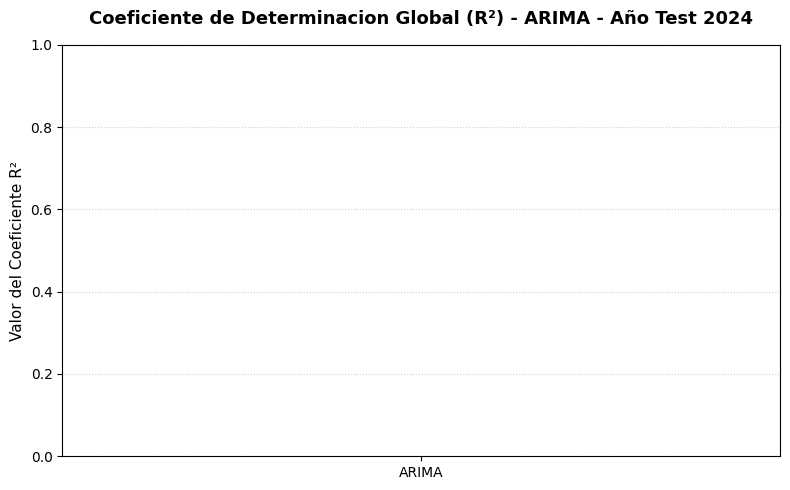

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 12. VISUALIZACION DE METRICAS GLOBALES DE PRECISION (ROBUSTAS - ARIMA)
# =======================================================================================

# 1. Cargar el dataframe resumen generado en el paso anterior
df_resumen = pd.read_csv('resumen_metricas_globales_arima_2024.csv')

# Configuramos los modelos como indice para facilitar el grafico
df_resumen.set_index('Modelo', inplace=True)

# Definimos los colores oficiales para ARIMA
color_arima = '#2ca02c' # Verde

# ---------------------------------------------------------------------------------------
# GRAFICA A: METRICAS PORCENTUALES ROBUSTAS (wAPE vs sMAPE)
# ---------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# Seleccionamos unicamente las metricas que no generan ruido numerico
metricas_pct = ['wAPE (%)', 'sMAPE (%)']
x = np.arange(len(metricas_pct))
ancho_barra = 0.4

# Dibujamos las barras para ARIMA
ax.bar(x, df_resumen.loc['ARIMA', metricas_pct], width=ancho_barra, label='ARIMA', color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.7)

# Formato academico para el analisis porcentual robusto
ax.set_title('Metricas del Error Porcentual Robusto - ARIMA (Año Test 2024)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Error Porcentual (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metricas_pct, fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=10)

# Añadir etiquetas de valor exacto encima de cada barra
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_errores_porcentuales_arima_2024.png', dpi=300)
plt.show()

# ---------------------------------------------------------------------------------------
# GRAFICA B: COMPORTAMIENTO DEL R² (BONDAD DE AJUSTE GLOBAL)
# ---------------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))

modelos_nombres = df_resumen.index
r2_valores = df_resumen['R²']

barras_r2 = plt.bar(modelos_nombres, r2_valores, color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.7, width=0.5)

# Formato academico para el R2
plt.title('Coeficiente de Determinacion Global (R²) - ARIMA - Año Test 2024', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Valor del Coeficiente R²', fontsize=11)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.gca().set_axisbelow(True)

# Añadir el valor exacto encima de cada barra
for bar in barras_r2:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_r2_global_arima_2024.png', dpi=300)
plt.show()